# GoTriple metadata cleaning — strategies, queries and timings

Two problems, two sections:

- **[1. Authors](#1-authors)** — recovering broken names, and deciding which profiles are the same person
- **[2. Licenses](#2-licenses)** — recovering a usable license for documents that have none

Every subsection shows the same three things:

1. **the schema** — what the strategy tries, in order, and where it gives up
2. **the Elasticsearch query actually executed** — captured from `es_helpers.QUERY_LOG`, never retyped
3. **a live run**, timed

Everything runs against `triple-profiles-prod` / `triple-documents-prod` through
Elasticsearch. Credentials come from `.env`; see `src/es_helpers.py`.

> The three constants in the next cell drive everything. Samples are small so the
> notebook finishes in minutes; raise them to scale —
> cost is linear in the number of records, except where noted in §3.

In [1]:
import contextlib, io, json, time
import matplotlib.pyplot as plt
import pandas as pd

from src.es_helpers import last_query
from src import pipelines
from src.functions_license import build_license_query, count_elastic_documents
from src.functions_name import count_elastic_authors, NAME_FILTER_QUERIES

# ============================================================================
# INITIAL PARAMETERS - change these, re-run, everything below follows
# ============================================================================
AUTHOR_NAME     = "Wang, Y."   # the name searched in the disambiguation subsection (1.4)
AUTHOR_SAMPLE   = 100          # author profiles to pull per subsection  (1.1 - 1.4)
DOCUMENT_SAMPLE = 100          # documents to pull for license recovery  (2.3)
# ============================================================================

TIMINGS = {}
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3})
OK, BAD, ALT = "#4c72b0", "#c44e52", "#55a868"


@contextlib.contextmanager
def timed(label):
    """Record wall-clock time so §3 is measured, not guessed."""
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start
    print(f"[{label}] {TIMINGS[label]:.1f}s")


def quietly(function, *args, **kwargs):
    """Run a pipeline stage, capturing its per-record chatter."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        result = function(*args, **kwargs)
    return result, buffer.getvalue()


def digest(output, keep=("->", "*", "---")):
    """Print only the summary lines from captured pipeline output."""
    for line in output.splitlines():
        if line.strip().startswith(keep):
            print(line)


def params(**values):
    """Print the parameters a run was given, so every result is self-describing."""
    width = max(len(k) for k in values)
    print("parameters")
    for key, value in values.items():
        print(f"  {key.replace('_', ' '):<{width}} : {value}")
    print()


def show_query(index_contains, title="query executed"):
    entry = last_query(index_contains)
    print(f"{title} — index: {entry['index']}")
    print(json.dumps(entry["body"], indent=2, ensure_ascii=False))

---
# 1. Authors

`triple-profiles-prod` holds 23.7M author profiles. Two unrelated problems live here.

**A name can be broken in several distinct ways**, and they do not respond to the
same treatment at all:

| §  | problem | profiles | outlook |
|----|---------|---------:|---------|
| 1.1 | an ORCID sits inside the name | 2,864 | almost all recoverable |
| 1.2 | the name is empty | 2,037 | rarely recoverable |
| 1.3 | the name is a URL or bare digits | 1,802 | rarely recoverable |

**Separately**, many profiles that *have* a fine name are duplicates of each
other (§1.4). That is a different question — not *what is this person called*
but *are these records the same person* — and it is solved by clustering, not
by lookups.

## 1.1 Names with an ORCID inside

The highest-yield repair in the project. The field holds the identifier, alone
or stuck onto a real name:

```
 '0000-0002-1588-0683'
 'Ana Morales, 0000-0001-6969-2883'
 'https://orcid.org/0000-0003-4140-8101'
 'Ardeshir Bazrkar orcid'                 ← the word survived, the id did not
```

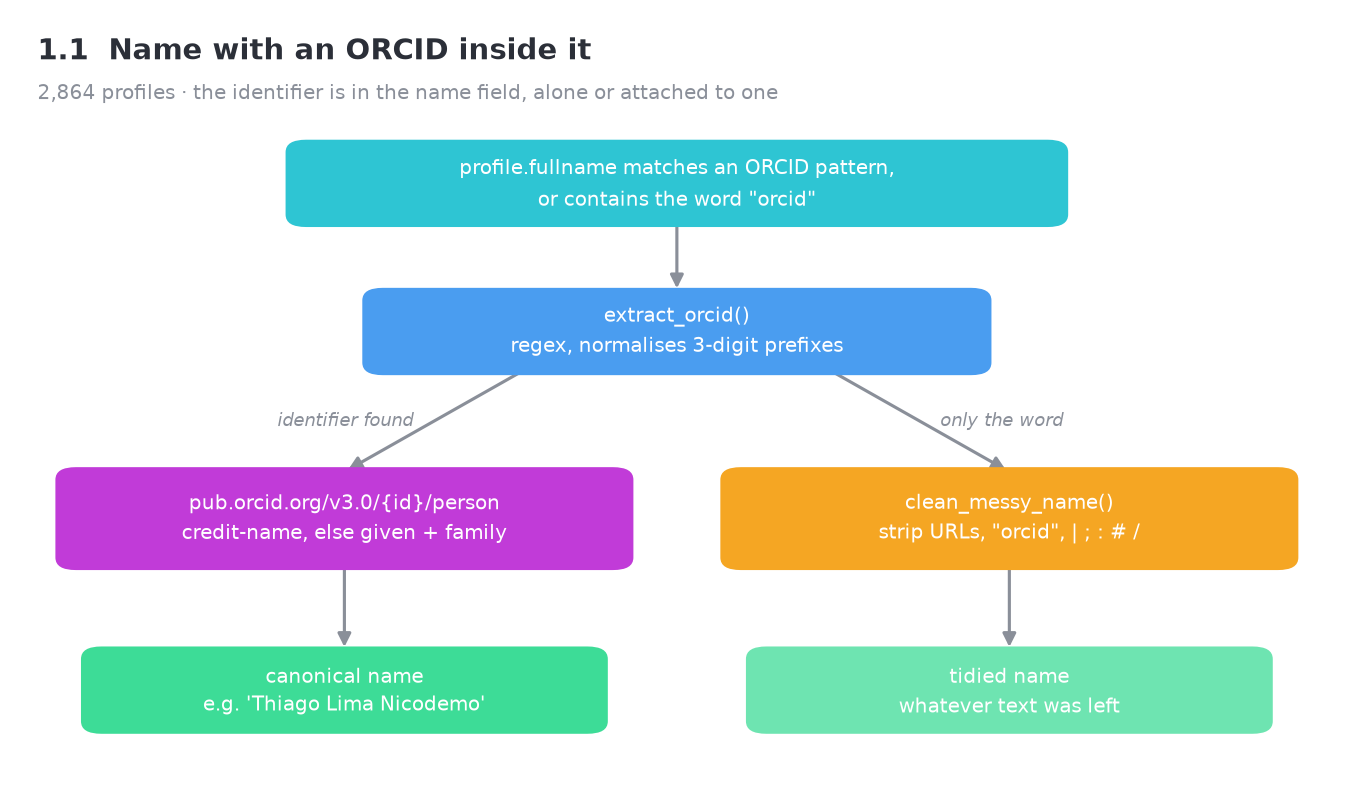

**Checking the documents index first would be wasted work.** The document holds
the *identical* broken string — GoTriple copies the name from it:

```
profile : 'Ana Morales, 0000-0001-6969-2883'
document: ['Ana Morales, 0000-0001-6969-2883']
```

ORCID is the only source that actually knows the person's name, so the pipeline
goes straight there whenever an identifier is present.

In [2]:
print(f"profiles with an ORCID in the name: {count_elastic_authors(name_filter='orcid'):,}")
print(json.dumps(NAME_FILTER_QUERIES["orcid"], indent=2))

profiles with an ORCID in the name: 2,869
{
  "bool": {
    "should": [
      {
        "regexp": {
          "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
        }
      },
      {
        "match": {
          "fullname": "orcid"
        }
      }
    ],
    "minimum_should_match": 1
  }
}


In [3]:
params(task="orcid_names", index="triple-profiles-prod", source="elastic",
       selection="fullname matches an ORCID pattern, or contains 'orcid'",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='orcid'):,}")

with timed("1.1 names: orcid inside"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="orcid_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : orcid_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname matches an ORCID pattern, or contains 'orcid'
  records requested : 100
  population        : 2,869



[1.1 names: orcid inside] 53.6s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "bool": {
      "should": [
        {
          "regexp": {
            "fullname.keyword": ".*[0-9]{4}-[0-9]{4}-[0-9]{4}-[0-9X]{4}.*"
          }
        },
        {
          "match": {
            "fullname": "orcid"
          }
        }
      ],
      "minimum_should_match": 1
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'orcid only': 67, 'orcid embedded in name': 32, 'stray orcid word': 1}
--- Name recovery by problem ---
     * orcid embedded in name     32/32   recovered
     * orcid only                 67/67   recovered
     * stray orcid word            1/1    recovered
-> Author data saved to '/Users/paulopiimenta/projects/lumen/43_metadata/data/output/authors_orcid_names_elastic.xlsx'
-> Candidates sharing an ORCID : 2 records (across 1 unique ORCIDs)
     * ORCID: 0000-0002-8279-

In [4]:
orcid_names = pd.read_excel("data/output/authors_orcid_names_elastic.xlsx")
print(orcid_names[["fullname", "fullname_fix", "name_source"]].head(8).to_string(index=False))

                                   fullname         fullname_fix name_source
                        0000-0002-1588-0683 Thiago Lima Nicodemo   orcid api
        Andrea Demaria, 0000-0002-5450-0444    Andrea L. Demaria   orcid api
          Anne Lutomia, 0000-0001-6029-8783 Anne Namatsi Lutomia   orcid api
           Ana Morales, 0000-0001-6969-2883          Ana Morales   orcid api
              0000-0002-5658-6085 Al Saffar     May Ali Alsaffar   orcid api
             Chad Laux, 0000-0001-7445-2446            Chad Laux   orcid api
Charles Joseph Stivale, 0000-0001-9893-6197      Charles Stivale   orcid api
       Corey S Seliger, 0000-0001-6100-3959        Corey Seliger   orcid api


## 1.2 Empty names

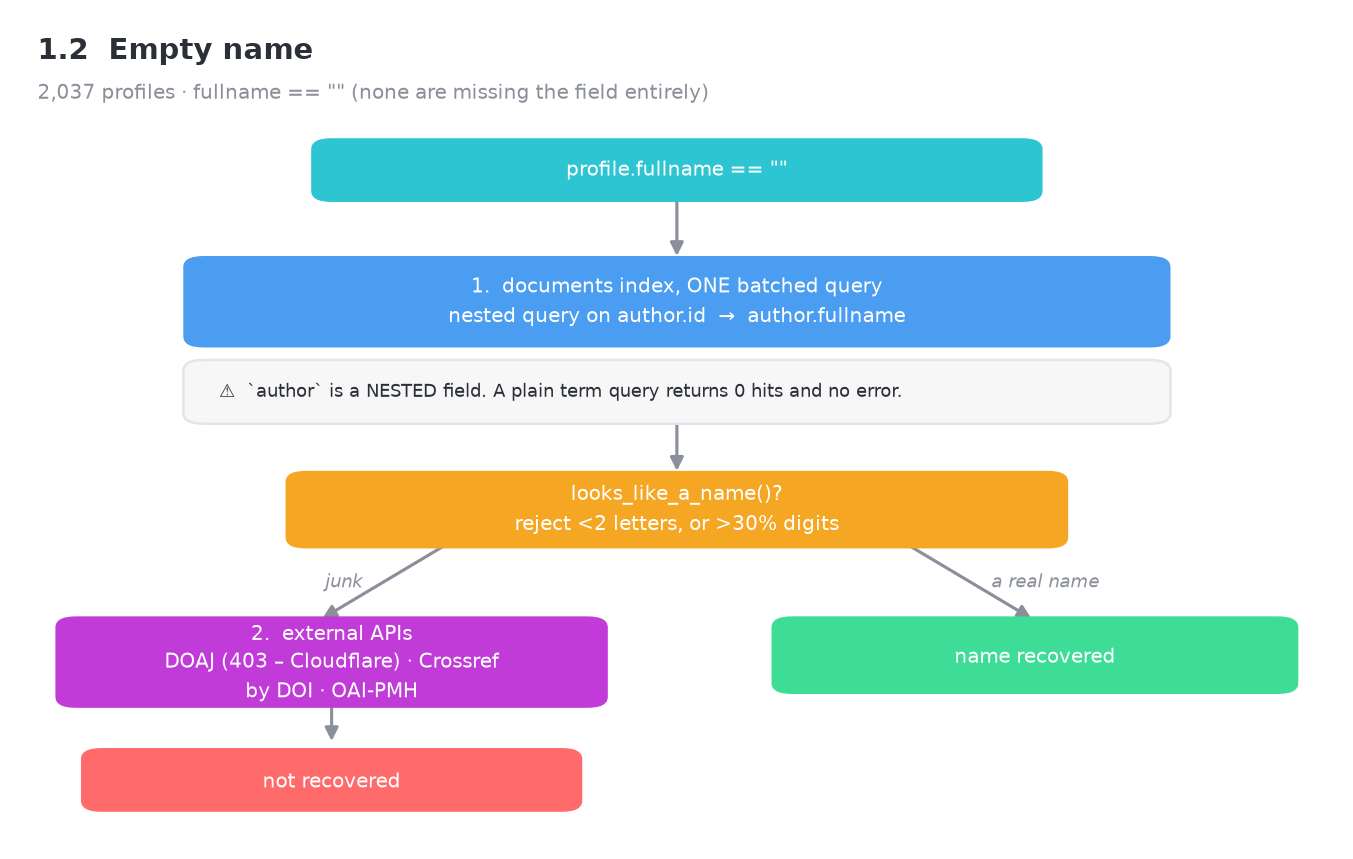

**Expect this to fail, and that is the finding.** Measured yield over 300 blank
profiles: **13 (4.3%)** — and most of those are not people:
`(Eds)`, `(sous la dir. de)`, `(pdf Formatında)`, `Author`.

These names are empty *because the source metadata was junk*. GoTriple blanked
them deliberately, and the document they came from still holds that same junk.

In [5]:
print(f"profiles with an empty name: {count_elastic_authors(name_filter='empty'):,}")
print(json.dumps(NAME_FILTER_QUERIES["empty"], indent=2))

profiles with an empty name: 2,039
{
  "term": {
    "fullname.keyword": ""
  }
}


In [6]:
params(task="empty_names", index="triple-profiles-prod", source="elastic",
       selection='fullname.keyword == ""',
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='empty'):,}")

with timed("1.2 names: empty"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="empty_names")

show_query("profiles", "\nselection query")
print()
digest(output)

parameters
  task              : empty_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname.keyword == ""
  records requested : 100
  population        : 2,039



[1.2 names: empty] 47.2s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "term": {
      "fullname.keyword": ""
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'empty': 100}
-> 0/100 recovered from the documents index
--- Name recovery by problem ---
     * empty                       0/100  recovered
-> Author data saved to '/Users/paulopiimenta/projects/lumen/43_metadata/data/output/authors_empty_names_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 0 records (across 0 unique clusters)
--- Disambiguation Results ---
------------------------------------------------------------
-> Failed to recover ORCID     : 100 records
-> Failed to retrieve Name     : 100 records


## 1.3 URL or bare-digit names

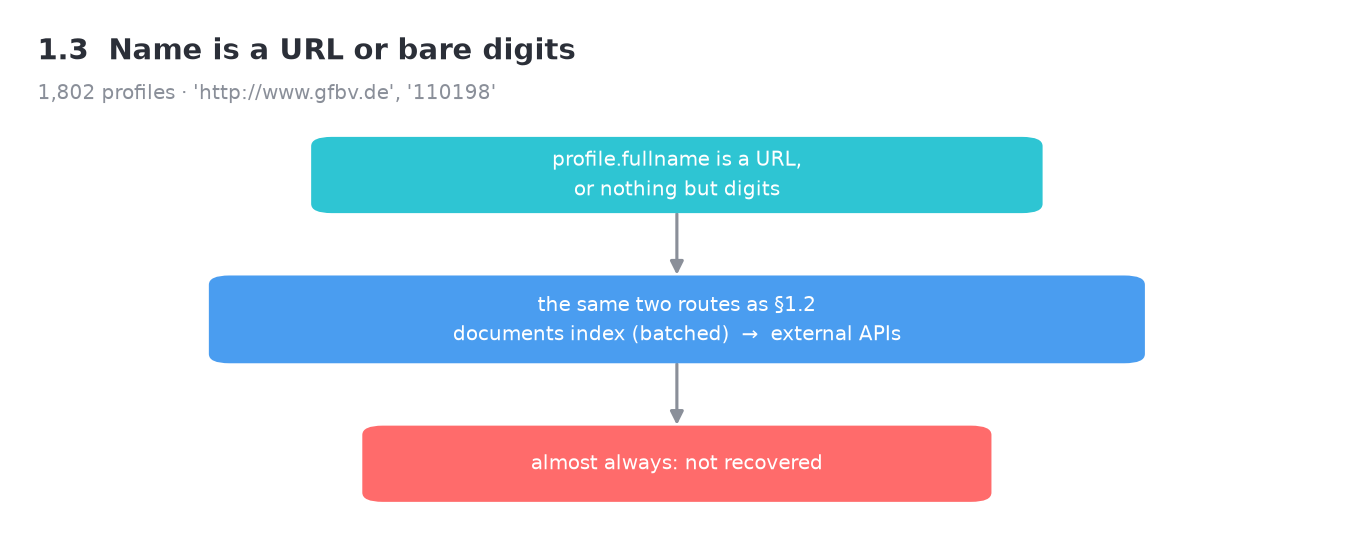

A URL is not a person and a record number is not a name. Included for
completeness, and to keep the arithmetic honest: a "fix" that returns `110198`
unchanged is reported as **not recovered**, never as a success —
`classify_name_problem()` is re-run on the result to decide that.

In [7]:
print(f"URL / numeric names: {count_elastic_authors(name_filter='junk'):,}")
print(json.dumps(NAME_FILTER_QUERIES["junk"], indent=2))

params(task="junk_names", index="triple-profiles-prod", source="elastic",
       selection="fullname is a URL or bare digits",
       records_requested=AUTHOR_SAMPLE, population=f"{count_elastic_authors(name_filter='junk'):,}")

with timed("1.3 names: url / numeric"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE)}, source="elastic", task="junk_names")
print()
digest(output)

URL / numeric names: 1,832
{
  "bool": {
    "should": [
      {
        "match": {
          "fullname": "http"
        }
      },
      {
        "regexp": {
          "fullname.keyword": "[0-9]+"
        }
      }
    ],
    "minimum_should_match": 1
  }
}


parameters
  task              : junk_names
  index             : triple-profiles-prod
  source            : elastic
  selection         : fullname is a URL or bare digits
  records requested : 100
  population        : 1,832



[1.3 names: url / numeric] 30.5s

--- STARTING AUTHOR NAME PIPELINE ---
-> what is wrong with them: {'numeric': 100}
-> 0/100 recovered from the documents index
--- Name recovery by problem ---
     * numeric                     0/100  recovered
-> Author data saved to '/Users/paulopiimenta/projects/lumen/43_metadata/data/output/authors_junk_names_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 0 records (across 0 unique clusters)
--- Disambiguation Results ---
------------------------------------------------------------
-> Failed to recover ORCID     : 100 records
-> Failed to retrieve Name     : 0 records


## 1.4 Disambiguation

Not *what is this person called* but *are these records the same person*. Split
into two phases so the second one is deterministic.

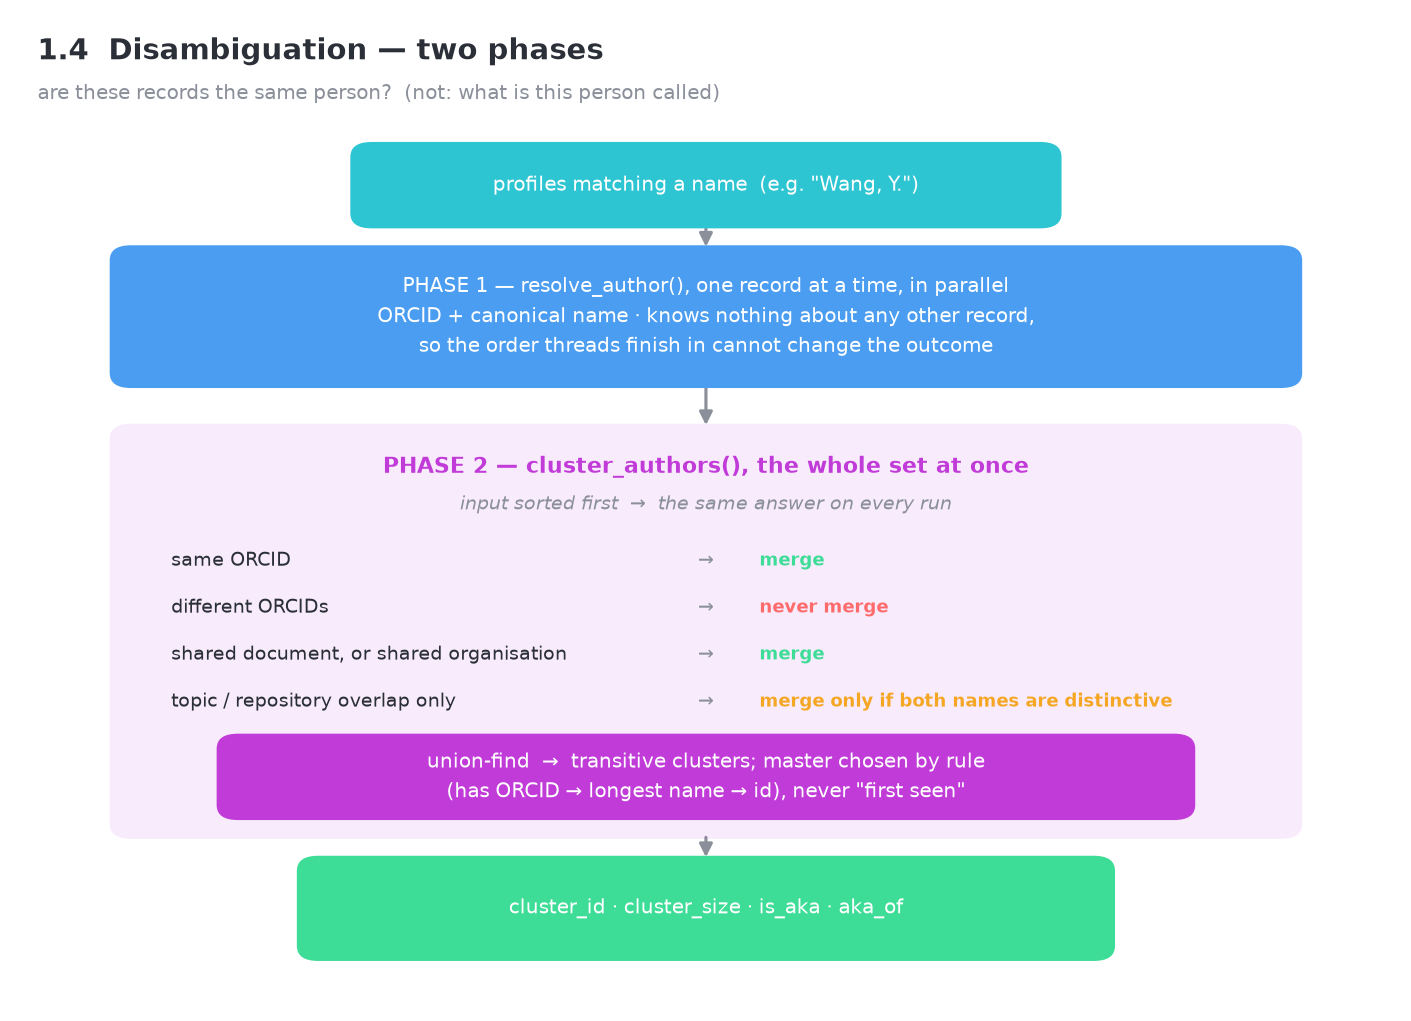

Why the "distinctive name" rule exists: 40 profiles named `Wang, Y.` share
**0 documents across 780 pairs**, but 264 of those pairs share a coarse topic
like `geo`. Merging on that evidence conflates strangers.

In [8]:
print(f"profiles matching {AUTHOR_NAME!r}: {count_elastic_authors(query=AUTHOR_NAME):,}")

params(task="disambiguate", strategy="cluster", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records_requested=AUTHOR_SAMPLE,
       population=f"{count_elastic_authors(query=AUTHOR_NAME):,}")

with timed("1.4 disambiguation: cluster"):
    _, output = quietly(pipelines.run_author_pipeline,
                        api_params={"size": str(AUTHOR_SAMPLE), "q": AUTHOR_NAME},
                        source="elastic", task="disambiguate", strategy="cluster")

show_query("profiles", "\nselection query")
print()
digest(output)

profiles matching 'Wang, Y.': 2,552


parameters
  task              : disambiguate
  strategy          : cluster
  index             : triple-profiles-prod
  source            : elastic
  name searched     : Wang, Y.
  records requested : 100
  population        : 2,552



[1.4 disambiguation: cluster] 44.2s

selection query — index: triple-profiles-prod
{
  "size": 100,
  "query": {
    "match": {
      "fullname": {
        "query": "Wang, Y.",
        "operator": "and"
      }
    }
  },
  "sort": [
    {
      "_score": "desc"
    },
    {
      "id": "asc"
    }
  ],
  "from": 0
}

--- STARTING AUTHOR NAME PIPELINE ---
-> 100 distinct identities, 0 records merged into them
-> Author data saved to '/Users/paulopiimenta/projects/lumen/43_metadata/data/output/authors_disambiguation_cluster_elastic.xlsx'
-> Candidates sharing an ORCID : 0 records (across 0 unique ORCIDs)
-> Candidates sharing a resolved Name : 95 records (across 4 unique clusters)
     * Master Name: Gershtein, Y. | Found in 4 records (ORCID's : None found)
     * Master Name: Pakhotin, Y. | Found in 4 records (ORCID's : None found)
     * Master Name: Wang, Y. | Found in 80 records (ORCID's : None found)
     * Master Name: Wang, Y. Y. | Found in 7 records (ORCID's : None found)
--- Di

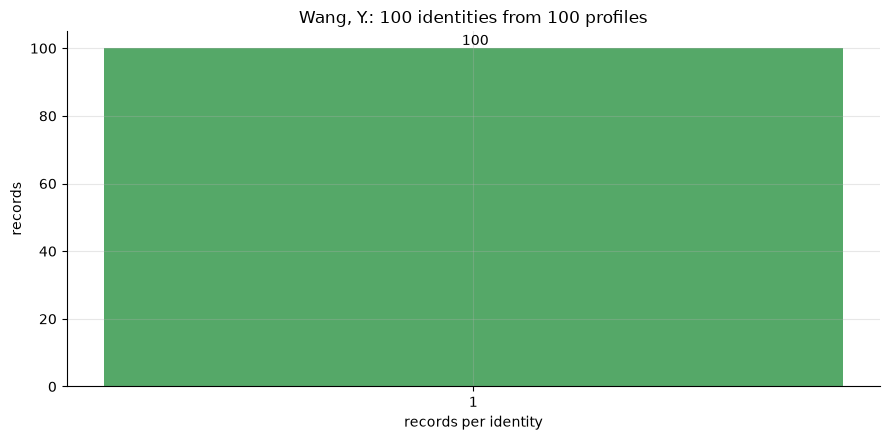

In [9]:
clustered = pd.read_excel("data/output/authors_disambiguation_cluster_elastic.xlsx")
sizes = clustered["cluster_size"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(sizes.index.astype(str), sizes.values, color=ALT)
ax.set_xlabel("records per identity"); ax.set_ylabel("records")
ax.set_title(f"{AUTHOR_NAME}: {clustered['cluster_id'].nunique()} identities "
             f"from {len(clustered)} profiles")
for i, v in enumerate(sizes.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

In [10]:
sizes = clustered["cluster_size"].value_counts().sort_index()
singletons = int(sizes.get(1, 0))
print(f"cluster sizes for {AUTHOR_NAME!r}:")
for size, count in sizes.items():
    print(f"  {count:>4} records sit in a cluster of {size}")
print(f"\n{singletons} of {len(clustered)} records are a cluster of one -> "
      f"{'no two profiles were judged the same person' if singletons == len(clustered) else 'some merged'}")
print(f"distinct identities: {clustered['cluster_id'].nunique()}")

cluster sizes for 'Wang, Y.':
   100 records sit in a cluster of 1

100 of 100 records are a cluster of one -> no two profiles were judged the same person
distinct identities: 100


### Reading that result

**0 merged means no cluster was formed.** Every one of the 100 profiles is its
own identity — a cluster of size 1. Clustering did not fail to run; it ran and
found nothing that would justify joining any two records:

| evidence | present? |
|---|---|
| same ORCID | none of the 100 has an ORCID at all |
| shared document | 0 of 4,950 pairs — and still 0 after adding what the documents index knows |
| shared organisation | the profiles index has no `current_organization` field |
| distinctive name + topic overlap | the name is initials-only, so this rule is deliberately blocked |

The only thing these records have in common is a surname and an initial, in 7
spelling variants, shared by 2,548 profiles. That is not evidence of identity.

**The heuristic's "9 identities, 91 merged" means it formed 9 groups** covering
all 100 records: 9 became registry masters and 91 were folded into them. It
accepted name-similarity plus a coarse shared topic (`geo`, `envir`) as proof,
which is how 100 records describing many different people collapse into 9.

Which is right? Neither is provably correct without ground truth — but a false
merge silently fuses two researchers' publication lists, while a missed merge
leaves a duplicate for a human to spot. This pipeline prefers the second, so
with no evidence it splits.

### 1.4.1 How the old heuristic works

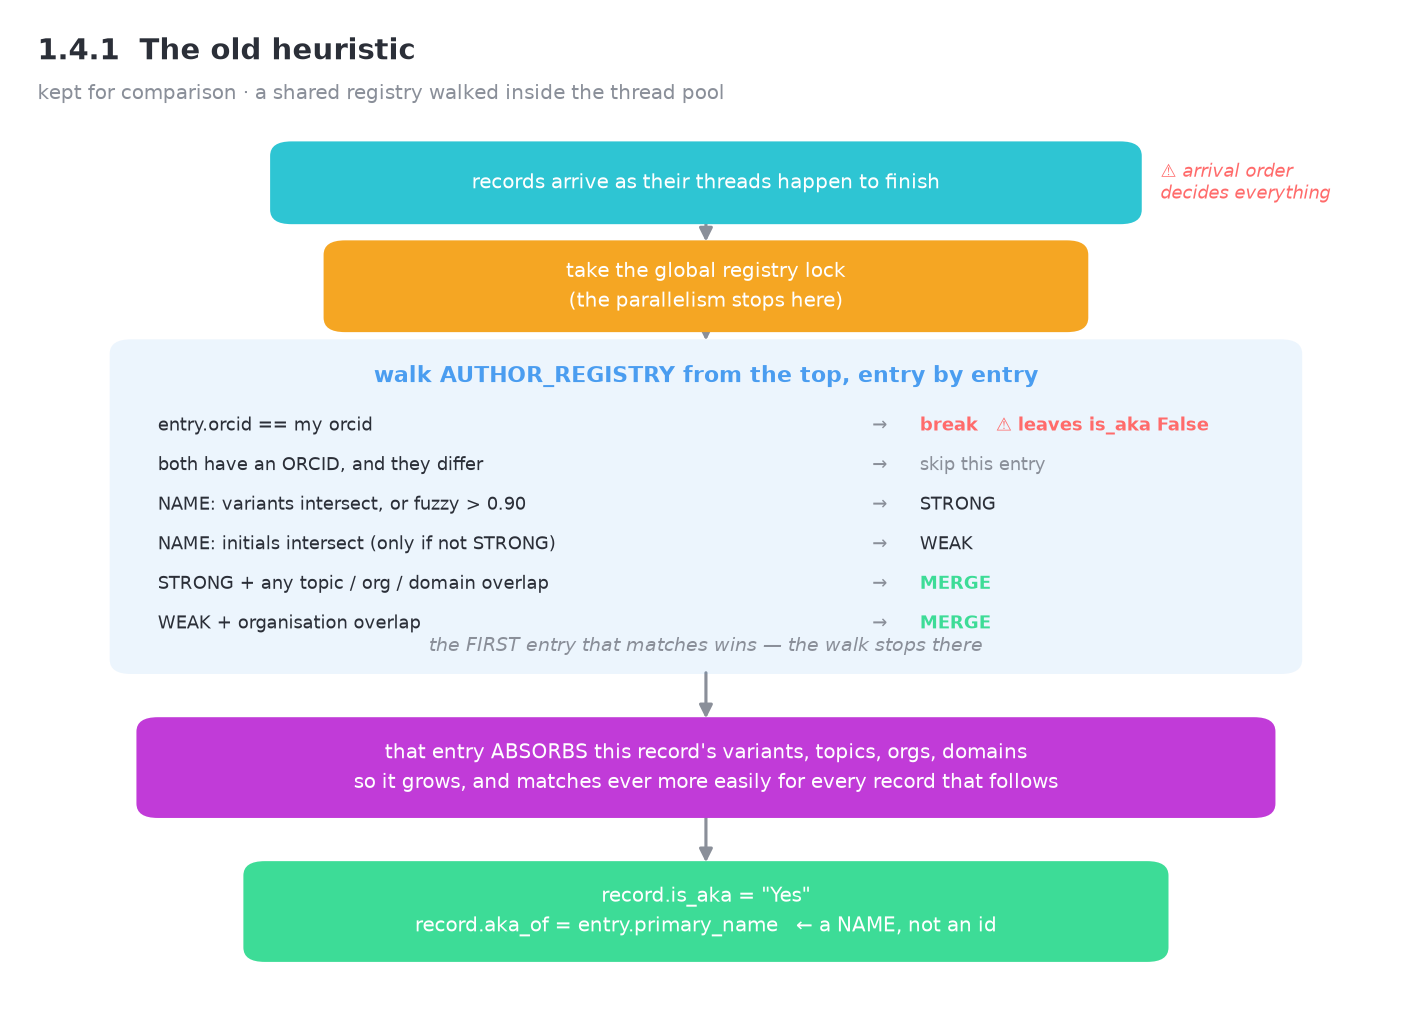

Four consequences follow from that shape:

**1. The answer depends on arrival order.** Records are consumed as futures
complete, so network timing decides which record becomes a master and which gets
absorbed. The same input produced 7 identities on one run and 8 on the next.

**2. Groups snowball.** Every merge widens the entry's name variants and context
sets, so an entry that has absorbed a few records matches almost anything that
follows. That is how 95 of 100 profiles ended up behind one master.

**3. Identity is recorded as a name.** `aka_of` holds `entry.primary_name`, so two
distinct groups whose masters share a name become indistinguishable downstream —
measured on this data: 9 groups, only 5 distinct master names, 5 of the 9 all
called `Wang, Y.`

**4. The ORCID shortcut does not merge anything.** Its body was left as
`# ... [existing shortcut code] ...` followed by `break`. Breaking leaves
`is_aka` False, so the record falls past the loop into
`if not is_aka: AUTHOR_REGISTRY.append(...)` and is registered as a **new**
author. The strongest identity evidence available is silently discarded — the
next cell demonstrates it.

In [11]:
import src.functions_name as fn

# Two records, same ORCID. Nothing is more definitive than that.
same_orcid = [
    {"fullname": "J. Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
    {"fullname": "John Smith 0000-0002-1825-0097", "author_of": [], "topic": ["phys"],
     "current_organization": []},
]

fn.AUTHOR_REGISTRY.clear()
resolved, _ = quietly(lambda rs: [fn.process_author(dict(r)) for r in rs], same_orcid)

for record in resolved:
    print(f"{record['fullname_fix']:20} orcid={record['id_fix']}  is_aka={record['is_aka']}")
print(f"registry entries: {len(fn.AUTHOR_REGISTRY)} (should be 1)")
print()
print("Both records resolve to the same person via the same ORCID, and the")
print("heuristic still files them as two separate identities. cluster_authors()")
print("merges them - it is the first rule in the evidence table above.")

Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=No
Josiah Carberry      orcid=0000-0002-1825-0097  is_aka=No
registry entries: 2 (should be 1)

Both records resolve to the same person via the same ORCID, and the
heuristic still files them as two separate identities. cluster_authors()
merges them - it is the first rule in the evidence table above.


### 1.4.2 The same data through the old heuristic

Kept for comparison. It walks a shared registry *inside* the thread pool, so the
answer depends on which future finishes first — run it twice and the counts move.

In [12]:
import random
import src.functions_name as fn
from src.functions_name import fetch_elastic_authors

sample = fetch_elastic_authors(size=str(AUTHOR_SAMPLE), query=AUTHOR_NAME)

params(task="disambiguate", strategy="heuristic", index="triple-profiles-prod", source="elastic",
       name_searched=AUTHOR_NAME, records=len(sample), runs="2 (different input orders)")

heuristic_runs, heuristic_groups = {}, {}

with timed("1.4 disambiguation: heuristic"):
    for seed in (1, 2):
        fn.AUTHOR_REGISTRY.clear()
        shuffled = [dict(a) for a in sample]
        random.Random(seed).shuffle(shuffled)
        quietly(lambda rs: [fn.process_author(r) for r in rs], shuffled)
        heuristic_runs[seed] = shuffled
        heuristic_groups[seed] = len(fn.AUTHOR_REGISTRY)  # the real number of groups
        merged = sum(1 for r in shuffled if r.get("is_aka") == "Yes")
        print(f"  run {seed}: {len(shuffled) - merged} identities, {merged} merged")

parameters
  task          : disambiguate
  strategy      : heuristic
  index         : triple-profiles-prod
  source        : elastic
  name searched : Wang, Y.
  records       : 100
  runs          : 2 (different input orders)



  run 1: 9 identities, 91 merged


  run 2: 9 identities, 91 merged
[1.4 disambiguation: heuristic] 156.5s


### 1.4.3 Clusters as bubbles

One bubble per **cluster actually formed** — a group of two or more profile
records judged to be the same person. Singletons are left out: a profile that
merged with nothing is not a cluster, and 100 identical dots say nothing. The
title carries the count that matters instead: how many of the profiles ended up
inside a cluster at all.

**The heuristic row is approximate, and that is itself a finding.** Clustering
emits a `cluster_id`, so its bubbles are exact. The heuristic only records the
master's *name* in `aka_of` — two groups whose masters share a name cannot be
told apart, so its bubble count comes out *lower* than the number of groups it
really formed. An identity key has to be an id, not a name.

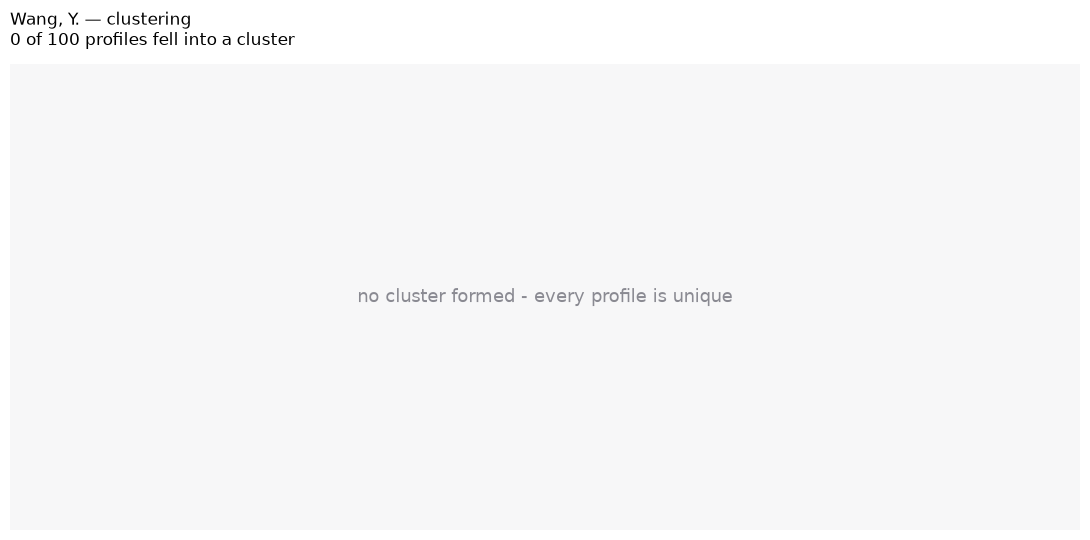

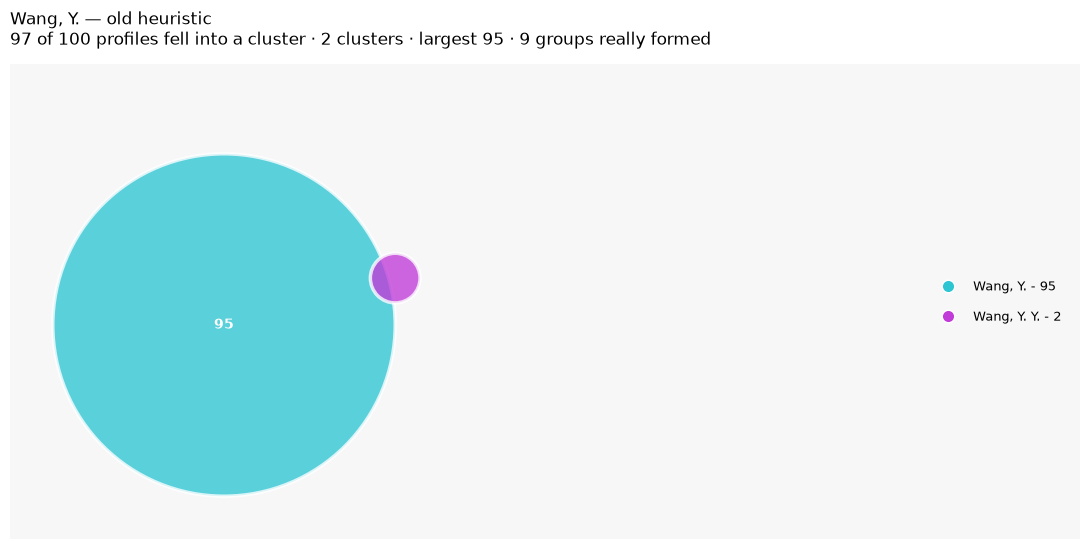

In [13]:
import collections
import numpy as np
from matplotlib.lines import Line2D

PALETTE = ["#2ec5d3", "#c13bd8", "#f5a623", "#4a9df0", "#7ed957", "#ff6b6b",
           "#9b6bff", "#3ddc97", "#ff9f43", "#5f27cd"]


def clusters_from_clustering(frame):
    """(label, size) per cluster_id - exact, because the id is real."""
    records = frame.to_dict("records")
    sizes = collections.Counter(r["cluster_id"] for r in records)
    masters = {r["cluster_id"]: (r.get("fullname_fix") or r.get("fullname"))
               for r in records if r.get("is_aka") == "No"}
    return [(str(masters.get(cid, cid)), n) for cid, n in sizes.most_common()]


def clusters_from_heuristic(records):
    """(label, size) keyed by the master's NAME - all `aka_of` offers."""
    keys = [r.get("aka_of") or r.get("fullname") for r in records]
    return [(str(k), n) for k, n in collections.Counter(keys).most_common()]


def pack(radii, gap=0.90):
    """Greedy circle packing: each bubble takes the first spiral position that
    does not overlap the ones already placed. Deterministic, and enough for the
    handful of clusters these runs produce."""
    placed = []
    for radius in radii:
        if not placed:
            placed.append((0.0, 0.0))
            continue
        for step in range(1, 4000):
            angle = step * 2.399963           # golden angle
            distance = 0.16 * np.sqrt(step)
            x, y = distance * np.cos(angle), distance * np.sin(angle)
            if all((x - px) ** 2 + (y - py) ** 2 >= (gap * (radius + pr)) ** 2
                   for (px, py), pr in zip(placed, radii)):
                placed.append((x, y))
                break
        else:
            placed.append((distance, distance))
    return placed


def bubble_chart(entries, total, title, note=None):
    """Bubbles for real clusters only; singletons are dropped by design."""
    clusters = [(label, size) for label, size in entries if size > 1]
    in_cluster = sum(size for _, size in clusters)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.set_facecolor("#f7f7f8")

    if not clusters:
        ax.text(.5, .5, "no cluster formed - every profile is unique",
                ha="center", va="center", fontsize=13, color="#8a8a92",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        counts = np.array([size for _, size in clusters], dtype=float)
        radii = np.sqrt(counts / counts.max())          # area proportional to records
        centres = pack(radii)

        handles = []
        for i, ((label, size), (x, y), radius) in enumerate(zip(clusters, centres, radii)):
            colour = PALETTE[i % len(PALETTE)]
            ax.add_patch(plt.Circle((x, y), radius, color=colour, alpha=.78,
                                    ec="white", lw=2.5, zorder=3))
            if radius > 0.28:
                ax.text(x, y, str(size), ha="center", va="center", zorder=4,
                        fontsize=10, color="white", fontweight="bold")
            handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                                  markerfacecolor=colour, markeredgecolor="white",
                                  label=f"{label[:28]} - {size}"))

        xs = [x for x, _ in centres]; ys = [y for _, y in centres]
        pad = radii.max() * 1.25
        ax.set_xlim(min(xs) - pad, max(xs) + pad * 3.2)   # room for the legend
        ax.set_ylim(min(ys) - pad, max(ys) + pad)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(handles=handles, loc="center right", frameon=False, fontsize=9,
                  labelspacing=1.3, borderpad=1, handletextpad=1.0)

    subtitle = f"{in_cluster} of {total} profiles fell into a cluster"
    if clusters:
        plural = "cluster" if len(clusters) == 1 else "clusters"
        subtitle += f" · {len(clusters)} {plural} · largest {clusters[0][1]}"
    if note:
        subtitle += f" · {note}"

    ax.set_title(f"{title}\n{subtitle}", fontsize=12, loc="left", pad=14)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    plt.tight_layout(); plt.show()
    return clusters


by_cluster = bubble_chart(clusters_from_clustering(clustered), len(clustered),
                          f"{AUTHOR_NAME} — clustering")

by_heuristic = bubble_chart(clusters_from_heuristic(heuristic_runs[1]), len(heuristic_runs[1]),
                            f"{AUTHOR_NAME} — old heuristic",
                            note=f"{heuristic_groups[1]} groups really formed")

In [14]:
print(f"clustering : {len(by_cluster)} clusters of 2+ records")
print(f"heuristic  : {len(by_heuristic)} clusters of 2+ records shown, "
      f"from {heuristic_groups[1]} groups it actually formed")
print()
print("Only the clustering figure can be trusted bubble-for-bubble: it groups on")
print("cluster_id. The heuristic groups on the master's name, so distinct groups")
print("sharing a name collapse into one bubble.")

clustering : 0 clusters of 2+ records
heuristic  : 2 clusters of 2+ records shown, from 9 groups it actually formed

Only the clustering figure can be trusted bubble-for-bubble: it groups on
cluster_id. The heuristic groups on the master's name, so distinct groups
sharing a name collapse into one bubble.


---
# 2. Licenses

`triple-documents-prod` holds 40.1M documents. **38.2M of them have no usable
license** — the single largest data-quality gap in GoTriple.

## 2.1 What "no usable license" means

`license` is an array, and three different values all mean *nothing usable*:

| value | documents |
|---|---:|
| `undefined` | 36,796,871 |
| `other` | 1,717,258 |
| `""` | 0 |
| field absent | 167 |

They are **one population, not three**: 537,761 documents carry both `other`
and `undefined` at once, so adding the buckets double-counts. The pipeline
treats them as a single "unresolved" group.

In [15]:
print(f"documents with no usable license: {count_elastic_documents('unresolved'):,}")
print(json.dumps(build_license_query("unresolved"), indent=2))

documents with no usable license: 38,325,285
{
  "bool": {
    "should": [
      {
        "terms": {
          "license": [
            "other",
            "undefined",
            ""
          ]
        }
      },
      {
        "bool": {
          "must_not": [
            {
              "exists": {
                "field": "license"
              }
            }
          ]
        }
      }
    ],
    "minimum_should_match": 1
  }
}


## 2.2 The recovery strategy

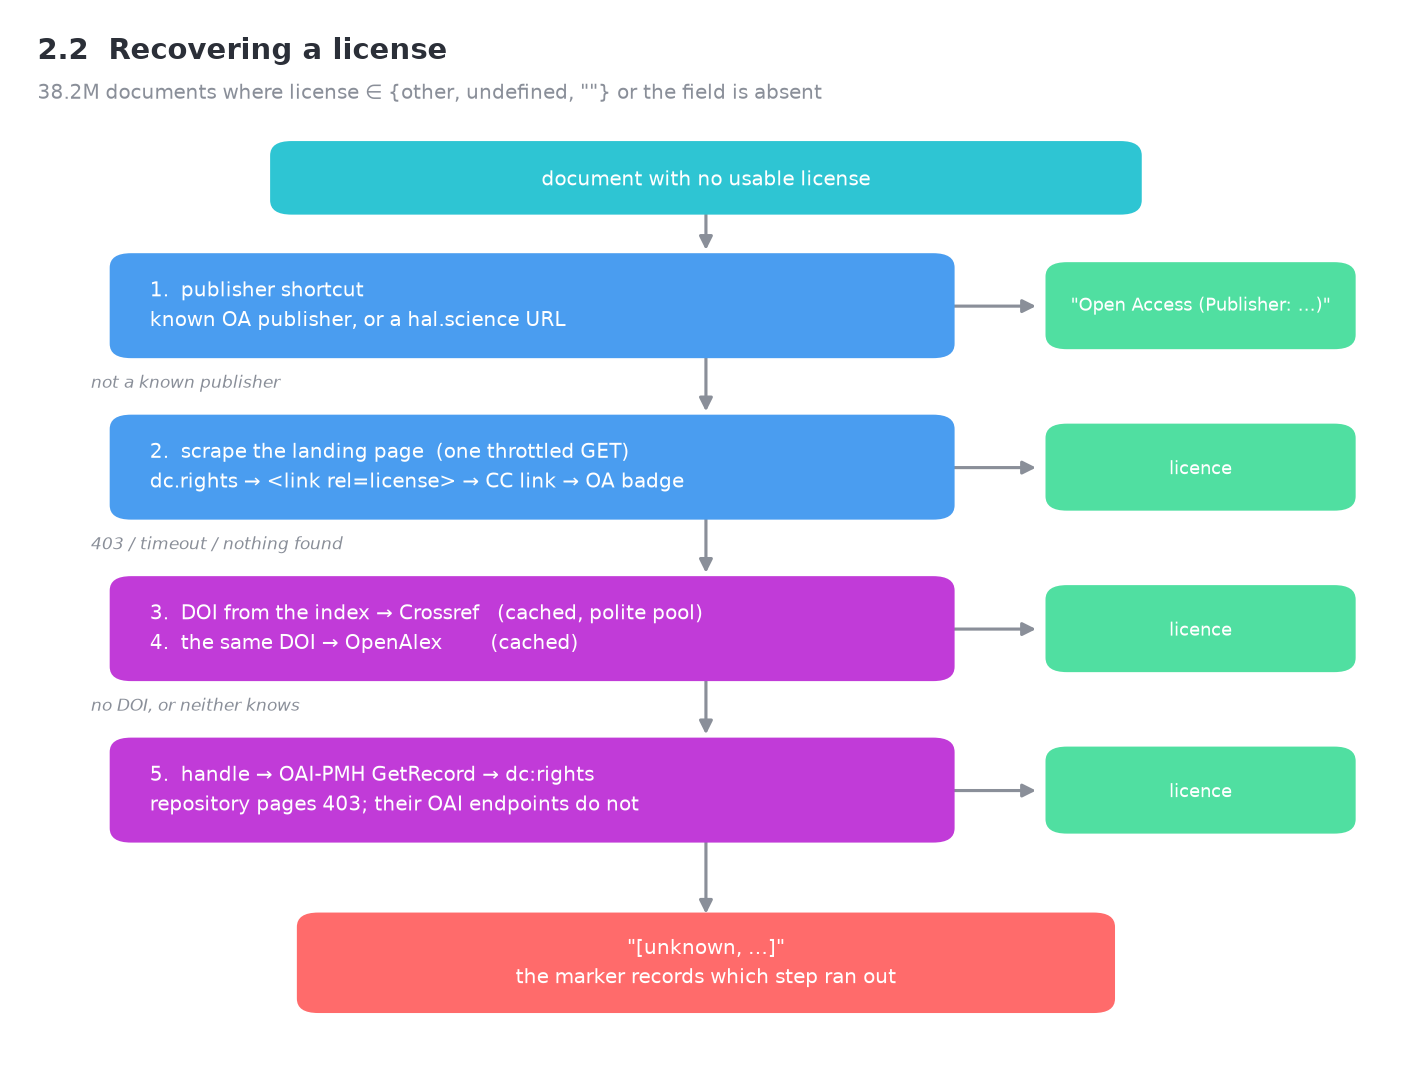

Steps 3–5 exist because scraping fails so often: **12.8% of landing pages answer
403**, concentrated in Cloudflare-protected hosts (doaj.org, hdl.handle.net,
ncbi, cairn). A realistic User-Agent recovered only 1 of 51 — these are
infrastructure blocks, not bot-sniffing — so the fix was to stop scraping those
and ask the metadata APIs instead, which lifted 403 recovery to 57% and overall recovery from 63.5% to 69%.

## 2.3 Run

In [16]:
params(task="license recovery", index="triple-documents-prod", source="elastic",
       selection='license in {other, undefined, ""} or absent',
       records_requested=DOCUMENT_SAMPLE, population=f"{count_elastic_documents('unresolved'):,}",
       max_workers=10)

with timed("2.3 licenses"):
    _, output = quietly(pipelines.run_license_pipeline,
                        num_docs=str(DOCUMENT_SAMPLE), source="elastic", max_workers=10)

show_query("documents", "\nselection query")
print()
digest(output)

parameters
  task              : license recovery
  index             : triple-documents-prod
  source            : elastic
  selection         : license in {other, undefined, ""} or absent
  records requested : 100
  population        : 38,325,286
  max workers       : 10



[2.3 licenses] 19.0s

selection query — index: triple-documents-prod
{
  "size": 100,
  "query": {
    "bool": {
      "should": [
        {
          "terms": {
            "license": [
              "other",
              "undefined",
              ""
            ]
          }
        },
        {
          "bool": {
            "must_not": [
              {
                "exists": {
                  "field": "license"
                }
              }
            ]
          }
        }
      ],
      "minimum_should_match": 1
    }
  },
  "sort": [
    {
      "id": "asc"
    }
  ]
}

--- STARTING DOCUMENT LICENSE PIPELINE ---
-> License data saved to '/Users/paulopiimenta/projects/lumen/43_metadata/data/output/license_fix_elastic.xlsx'
-> Documents in batch           : 100
-> Already had a license        : 0
-> Searched (unresolved group)  : 100
-> Licenses found               : 68 / 100 (68.0%)
-> Still unknown                : 32 (32.0%)
--- What was found ---
     * HAL Auth

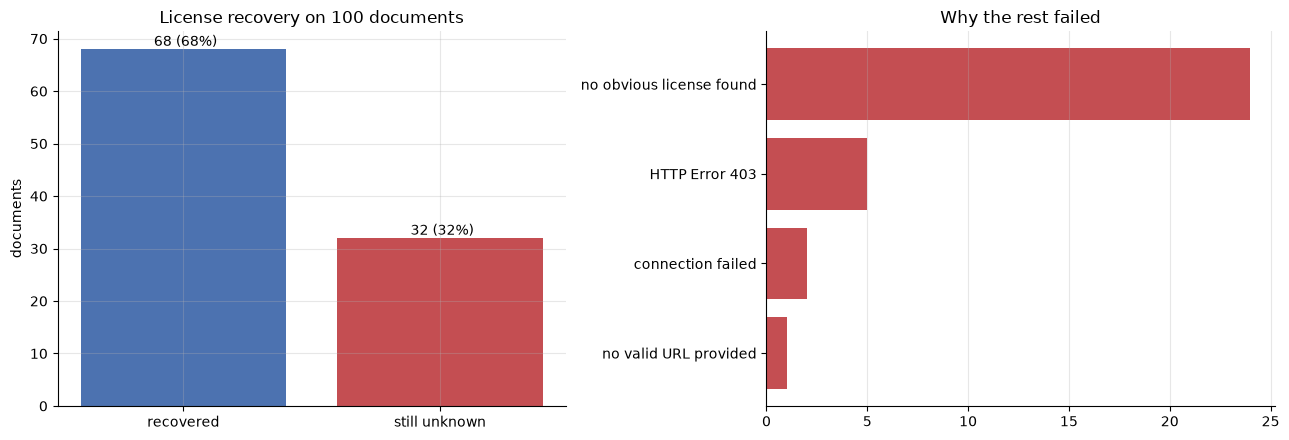

In [17]:
licenses = pd.read_excel("data/output/license_fix_elastic.xlsx")
result = licenses["scrapped_license"].astype(str)
searched = result[result != "Already classified"]
found = searched[~searched.str.startswith("[unknown")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["recovered", "still unknown"], [len(found), len(searched) - len(found)], color=[OK, BAD])
axes[0].set_title(f"License recovery on {len(searched)} documents")
axes[0].set_ylabel("documents")
for i, v in enumerate([len(found), len(searched) - len(found)]):
    axes[0].text(i, v, f" {v} ({100*v/len(searched):.0f}%)", ha="center", va="bottom")

reasons = searched[searched.str.startswith("[unknown")].value_counts().head(6)[::-1]
if len(reasons):
    axes[1].barh([r.strip("[]").replace("unknown, ", "")[:34] for r in reasons.index],
                 reasons.values, color=BAD)
axes[1].set_title("Why the rest failed")
axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

---
# 3. How long each solution takes

Measured on this run: `AUTHOR_SAMPLE` profiles for §1, `DOCUMENT_SAMPLE` documents for §2.

,solution,seconds,records,per record (s),"1,000 records"
0,1.1 names: orcid inside,53.6,100,0.536,8.9 min
1,1.2 names: empty,47.2,100,0.472,7.9 min
2,1.3 names: url / numeric,30.5,100,0.305,5.1 min
3,1.4 disambiguation: cluster,44.2,100,0.442,7.4 min
4,1.4 disambiguation: heuristic,156.5,100,1.565,26.1 min
5,2.3 licenses,19.0,100,0.190,3.2 min


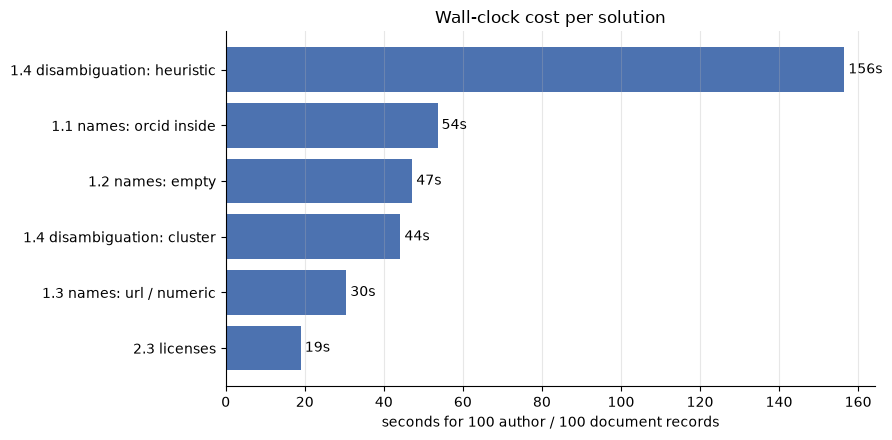

In [18]:
summary = pd.DataFrame({"solution": list(TIMINGS), "seconds": [round(v, 1) for v in TIMINGS.values()]})
summary["records"] = [DOCUMENT_SAMPLE if s.startswith("2.") else AUTHOR_SAMPLE for s in summary["solution"]]
summary["per record (s)"] = (summary["seconds"] / summary["records"]).round(3)
summary["1,000 records"] = (summary["per record (s)"] * 1000 / 60).round(1).astype(str) + " min"
display(summary)

fig, ax = plt.subplots()
ordered = summary.sort_values("seconds")
ax.barh(ordered["solution"], ordered["seconds"], color=OK)
ax.set_xlabel(f"seconds for {AUTHOR_SAMPLE} author / {DOCUMENT_SAMPLE} document records"); ax.set_title("Wall-clock cost per solution")
ax.grid(axis="y", visible=False)
for i, v in enumerate(ordered["seconds"]):
    ax.text(v, i, f" {v:.0f}s", va="center")
plt.tight_layout(); plt.show()

### What dominates each timing

| solution | the slow part |
|---|---|
| 1.1 orcid inside | one `pub.orcid.org` request per profile (~0.16s each, incl. a deliberate 0.1s spacing) |
| 1.2 / 1.3 empty, junk | one batched documents query for the whole set, then the same per-profile API pass |
| 1.4 disambiguation | phase 1 is per-profile HTTP; phase 2 is CPU-only and compares every pair |
| 2.3 licenses | one HTTP GET per landing page, throttled per host, plus the Crossref/OpenAlex fallbacks |

**Only phase 2 of clustering grows non-linearly.** It is O(n²) in the number of
records, so 10× the records is ~100× the clustering work. Everything else is
linear and I/O-bound, which also means it responds to more concurrency rather
than faster code.

Projecting the full populations from the per-record costs above: the author
name-repair jobs are minutes-to-hours, while all 38.2M unresolved documents
would be a multi-month run — that job needs to be scoped by provider or
license value, not run end to end.